In [33]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import numpy.ma as ma
import xarray as xr

## Planning to cover an aera by spirals but still scanning rays as far as feasible

## The area 

In [34]:
x = np.linspace(0, 5, num=100+1)
y = np.linspace(0, 5, num=100+1)

X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Phi = np.arctan2(Y, X)

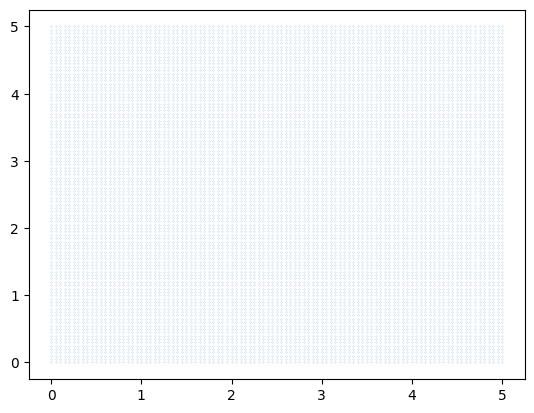

In [35]:
fig, ax = plt.subplots(1, 1)
ax.scatter(X.ravel(), Y.ravel(), s=1e-2)

## The pie

In [36]:
mask = np.zeros(Phi.shape, np.bool)

All data for R > 5

In [37]:
mask[R>5] = True

In [38]:
Phim = ma.masked_array(Phi, mask=mask)
Rm = ma.masked_array(R, mask=mask)

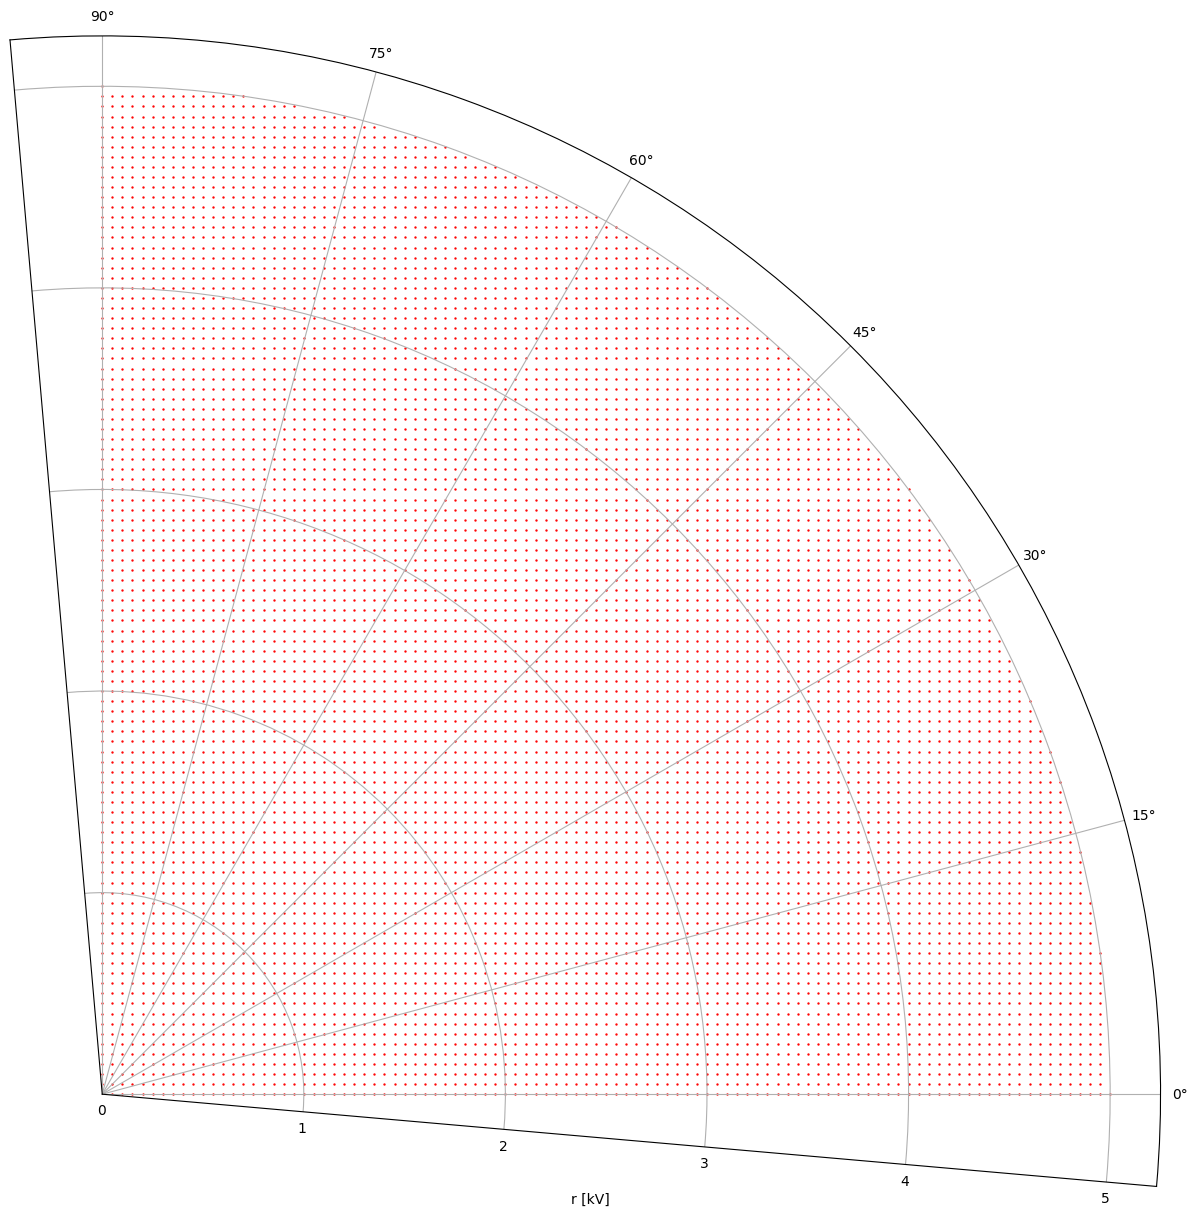

In [39]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[16, 16])
ax.clear()
ax.set_thetamin(-5)
ax.set_thetamax(95)
# ax.scatter(Phi.ravel(), R.ravel(), s=.1, color='b')
ax.scatter(Phim.ravel(), Rm.ravel(), s=.5, color='r')
ax.set_xlabel('r [kV]')

fig.subplots_adjust(bottom=0.1, right=0.85, top=0.9)

In [40]:
np.sum(mask == False)

np.int64(7953)

## Define rays... Cover the most extreme values first

###  copy from old bact ... 

Rearange index so that one starts at the exterem pooints and then always cut into the intervals

In [41]:
def combine_lists(minor_list, major_list):
    # Do the zip ... but they do not need to be of same length
    l_minor = len(minor_list)
    l_major = len(major_list)

    l_min = min(l_minor, l_major)
    trailing = minor_list[l_min:] + major_list[l_min:]

    zipped = []
    for a_min, a_maj in zip(minor_list[:l_min], major_list[:l_min]):
        zipped.append(a_min)
        zipped.append(a_maj)
    
    # XXX Check that only elements are missing on one side
    result = zipped + trailing
    return result

def extract_indices_sublist(sublist):
    """Create indices which allow extracting points always splitting the interval

    Args:
        sublist : a list of elements to rearange

    Calls function recursively. Rearanges all so that in the beginning the start
    and end points are chosen next to the middle point. Then the remaining part 
    is split up into two intervals. For each interval this functions is called 
    again
    """
    
    l = len(sublist)
    if l == 0:
        return []
    elif l == 1:
        return [sublist[0]]
    elif l in (2,3):
        return sublist
    else:
        # Need to process further
        pass

    
    l2 = l//2
    r = [sublist[l2]]
    
    minor_list = sublist[:l2]
    major_list = sublist[l2+1:]
    r_minor = extract_indices_sublist(minor_list)
    r_major = extract_indices_sublist(major_list)

    result = r + combine_lists(r_minor, r_major)
    return result


def extract_indices_list(a_list):
    """Create indices which allow extracting points always splitting the interval

    Args:
        sublist : a list of elements to rearange

    Calls function recursively. Rearanges all so that in the beginning the start
    and end points are chosen next to the middle point. Then the remaining part 
    is split up into two intervals. For each interval this functions is called 
    again
    
    """
    a_list = list(a_list)
    l = len(a_list)
    if l == 0:
        return []
    elif l == 1:
        return [a_list[0]]
    elif l in (2,3):
        return a_list
    else:
        # Need to process further
        pass

    
    l2 = l//2
    r = [a_list[0], a_list[-1], a_list[l2]]

    minor_list = a_list[1:l2]
    major_list = a_list[l2+1:-1]
    r_minor = extract_indices_sublist(minor_list)
    r_major = extract_indices_sublist(major_list)

    result = r + combine_lists(r_minor, r_major)
    return result


## select unused points as close as feasible on the grid

In [42]:
def create_rays_on_grid(Zm, phi, r, threshold):
    '''Select points from ZM using rays along phi and r
    
    Args:
        Zm:          a masked array of complex points. 
                     allows preexcluding points
        phi:         the different directions of the rays starting from the center
        r:           radial positions of the rays
        theshold ... maximum distance to accept as deviation
    '''
    Z = Zm.data.copy()
    mask = Zm.mask.copy()
    
    rays_ = []

    for p in phi:
        # Calculate in the complex
        zt = r * np.exp(p * 1j)
    
        # Mask already selected points
        # In the beginning mask should be set to the points outside the largest circle
        Zm = ma.masked_array(Z, mask=mask)
        Zmr = Zm.ravel()
    
        # distance to the points along the ray
        dZ = Zmr[np.newaxis, :] - zt[:, np.newaxis]
        dZa = np.absolute(dZ)
    
        # nearest point
        args = dZa.argmin(axis=1)
    
        # distance of selected to original point 
        dZsel = dZ[np.arange(zt.shape[0]), args]
        dZsela = np.absolute(dZsel)
    
        # only use those args for which the distance is below some thresod
        args = args[dZsela < threshold ]

        # avoid repetition of identical points 
        t_args = list(set(args.tolist()))
        Zsel = Zmr[t_args]
    
        # Sort the points by distance from center
        Zsel = Zsel.tolist()
        try:
            Zsel.sort(key=np.absolute)
        except:
            print(f'{Zsel=}')
            raise
        Zsel = np.array(Zsel)
        rays_.append(Zsel)
    
        # Mask already used points
        maskr = mask.ravel()
        maskr[args] = True
        mask = maskr.reshape(mask.shape)
        
    return rays_, mask


In [43]:
def rays_as_xarray(rays, min_radius=2.75):
    l = []
    ray_count = []
    n_radii = None
    for cnt, pos in enumerate(rays_):
        # Assume that the first ray is the longest one
        n_points = len(pos)
        if n_radii is None:
            n_radii = n_points
        tmp = np.zeros([n_radii, 5], float)
   
        t_r = np.absolute(pos)
        t_phi = np.arctan2(pos.imag, pos.real)
        if n_points < 5 or t_r.min() > min_radius:
            # Ray does not start close enough
            continue
        tmp[:n_points, 0] = pos.real
        tmp[:n_points, 1] = pos.imag
        tmp[:n_points, 2] = t_r
        tmp[:n_points, 3] = t_phi
        tmp[:n_points, 4] = True
        l.append(tmp)
        ray_count.append(cnt)
    
    r = xr.DataArray(data = l, dims = ['ray', 'num', 'coor'],
        coords = [ray_count, np.arange(n_radii), ['x', 'y', 'r', 'phi', 'valid']])
    return r

## Plan of the scans


### Total grid scan

Plan some rays first 

In [44]:
r2d = 180/np.pi

In [45]:
phi_ = np.linspace(0, np.pi/2, num=9 * 2 * 10 + 1)
phi_ = np.linspace(0, np.pi/2, num=9 * 10 + 1)
indices = extract_indices_list(np.arange(len(phi_)))
indices
assert(len(indices) ==  len(set(indices)))

In [46]:
phi = np.take(phi_, indices)
phi * r2d

array([ 0., 90., 45., 23., 68., 12., 57., 34., 79.,  6., 51., 29., 74.,
       18., 63., 40., 85.,  3., 48., 26., 71., 15., 60., 37., 82.,  9.,
       54., 32., 77., 21., 66., 43., 88.,  1., 46., 24., 69., 13., 58.,
       35., 80.,  7., 52., 30., 75., 19., 64., 41., 86.,  4., 49., 27.,
       72., 16., 61., 38., 83., 10., 55., 33., 78., 22., 67., 44., 89.,
        2., 47., 25., 70., 14., 59., 36., 81.,  8., 53., 31., 76., 20.,
       65., 42., 87.,  5., 50., 28., 73., 17., 62., 39., 84., 11., 56.])

In [47]:
r = np.linspace(0, 5, num=101)

In [48]:
R_rays, Phi_rays = np.meshgrid(r, phi)

In [49]:
print(phi * r2d)

[ 0. 90. 45. 23. 68. 12. 57. 34. 79.  6. 51. 29. 74. 18. 63. 40. 85.  3.
 48. 26. 71. 15. 60. 37. 82.  9. 54. 32. 77. 21. 66. 43. 88.  1. 46. 24.
 69. 13. 58. 35. 80.  7. 52. 30. 75. 19. 64. 41. 86.  4. 49. 27. 72. 16.
 61. 38. 83. 10. 55. 33. 78. 22. 67. 44. 89.  2. 47. 25. 70. 14. 59. 36.
 81.  8. 53. 31. 76. 20. 65. 42. 87.  5. 50. 28. 73. 17. 62. 39. 84. 11.
 56.]


In [50]:
Z = X + Y *1j

In [60]:
phi / np.pi * 180


array([ 0., 90., 45., 23., 68., 12., 57., 34., 79.,  6., 51., 29., 74.,
       18., 63., 40., 85.,  3., 48., 26., 71., 15., 60., 37., 82.,  9.,
       54., 32., 77., 21., 66., 43., 88.,  1., 46., 24., 69., 13., 58.,
       35., 80.,  7., 52., 30., 75., 19., 64., 41., 86.,  4., 49., 27.,
       72., 16., 61., 38., 83., 10., 55., 33., 78., 22., 67., 44., 89.,
        2., 47., 25., 70., 14., 59., 36., 81.,  8., 53., 31., 76., 20.,
       65., 42., 87.,  5., 50., 28., 73., 17., 62., 39., 84., 11., 56.])

In [61]:
r

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
       1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
       1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
       2.2 , 2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 ,
       2.75, 2.8 , 2.85, 2.9 , 2.95, 3.  , 3.05, 3.1 , 3.15, 3.2 , 3.25,
       3.3 , 3.35, 3.4 , 3.45, 3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.75, 3.8 ,
       3.85, 3.9 , 3.95, 4.  , 4.05, 4.1 , 4.15, 4.2 , 4.25, 4.3 , 4.35,
       4.4 , 4.45, 4.5 , 4.55, 4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85, 4.9 ,
       4.95, 5.  ])

In [51]:
Zm = ma.masked_array(Z, mask)
rays_, mask_remaining =  create_rays_on_grid(Zm, phi, r, threshold=.05)

In [52]:
rays = rays_as_xarray(rays_);

In [53]:
planned_scans = xr.DataArray(dims=['r', 'phi'], coords=[r, phi])

In [54]:
rays.to_netcdf('pie_planned_scans.nc')

ValueError: cannot write NetCDF files because none of the suitable backend libraries (netCDF4, h5netcdf, scipy) are installed

In [55]:
Phim2 = ma.masked_array(Phi, mask=mask_remaining)
Rm2 = ma.masked_array(R, mask=mask_remaining)

def process(mat):
    vec = np.ravel(mat)
    return vec.data[~vec.mask]

pPhim2 = process(Phim2)
pRm2 = process(Rm2)

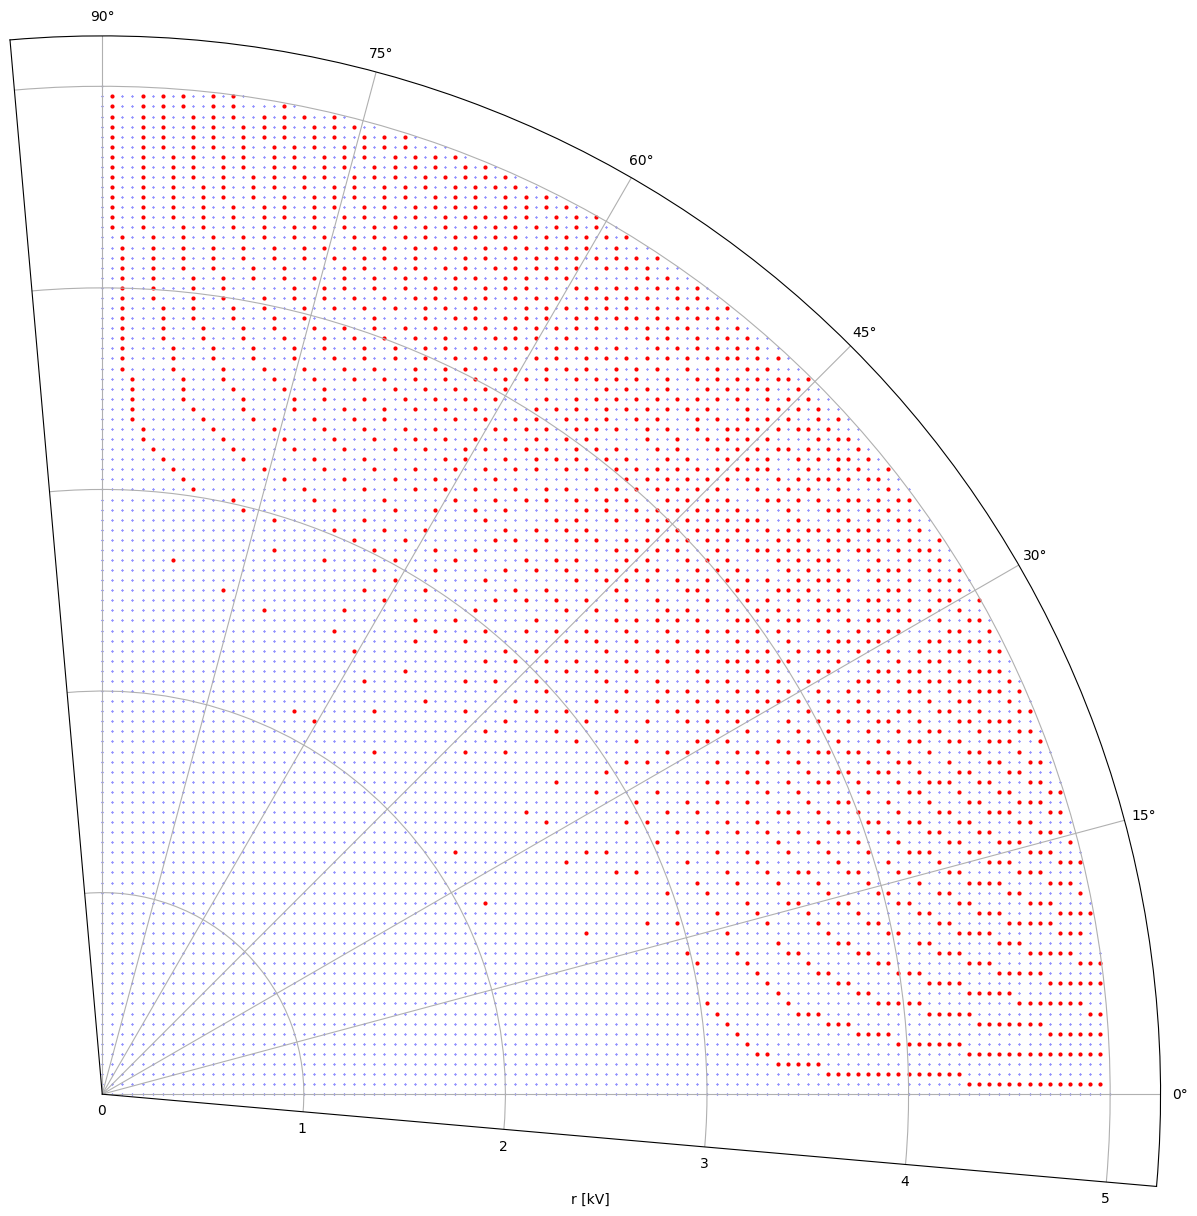

In [56]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[16, 16])
ax.clear()
ax.set_thetamin(-5)
ax.set_thetamax(95)
ax.scatter(Phim.ravel(), Rm.ravel(), s=.1, color='b')
Phimplot = Phim2.ravel
ax.scatter(pPhim2, pRm2, s=4, color='r')
# ax.scatter(Phi_rays.ravel(), R_rays.ravel(), s=2, color='k')

ax.set_xlabel('r [kV]')
# ax.set_rmax(1)
fig.subplots_adjust(bottom=0.1, right=0.85, top=0.9)

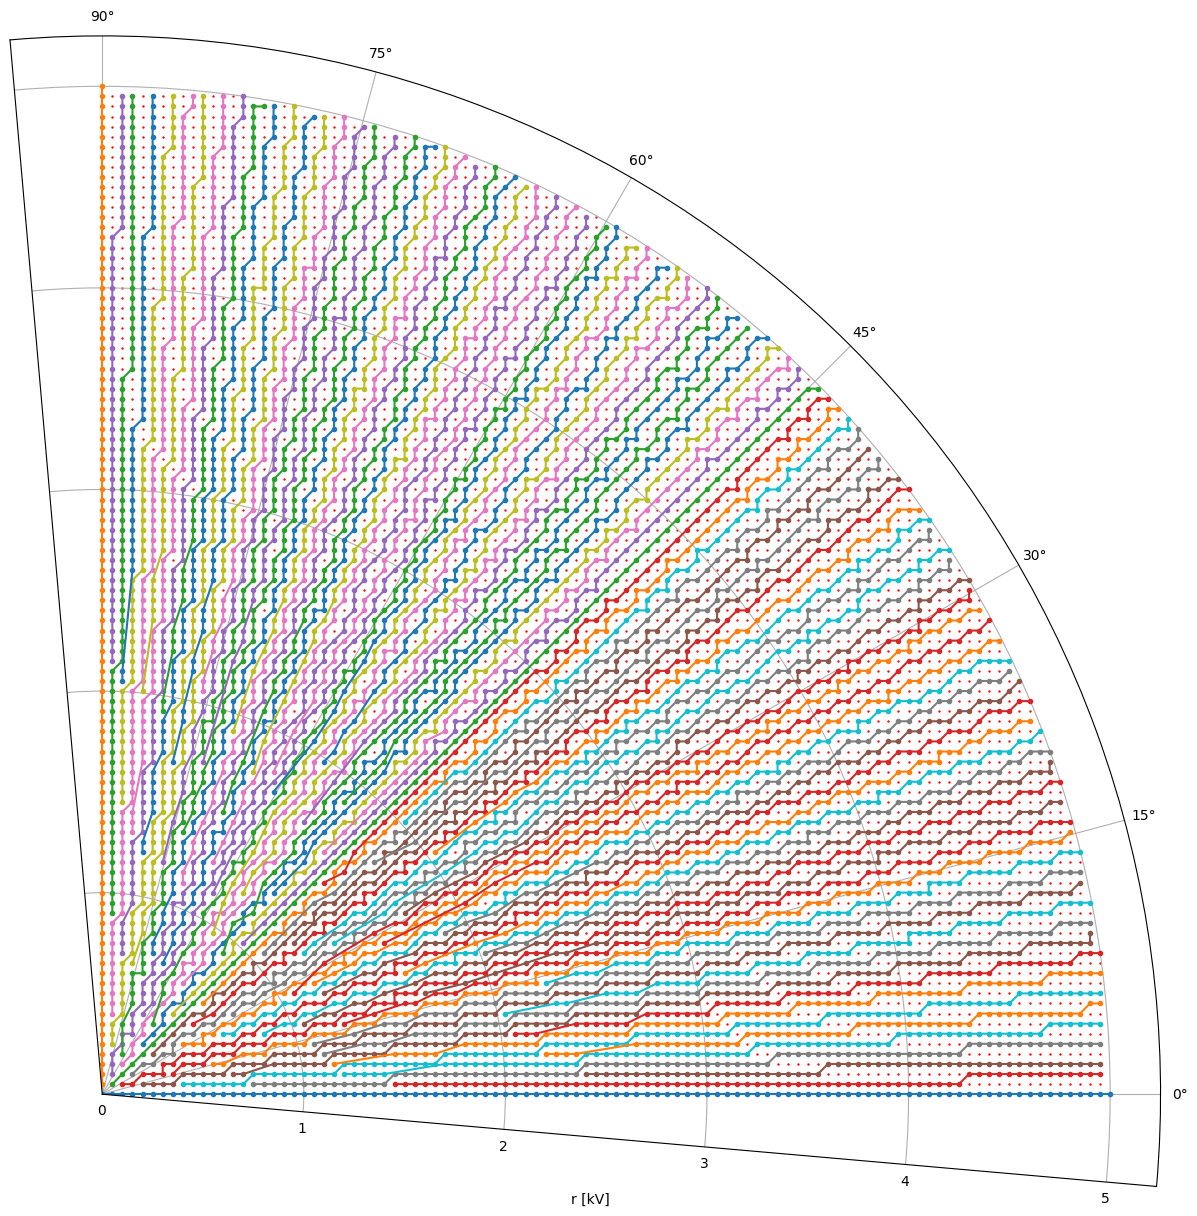

In [57]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[16, 16])
ax.clear()
ax.set_thetamin(-5)
ax.set_thetamax(95)
ax.scatter(Phim.ravel(), Rm.ravel(), s=.5, color='r')

# ax.plot([np.pi/8, np.pi/8], [1, 5], 'k-', linewidth=2)
# plot the scan rays
for ray_num in rays.coords['ray']:
    ray_data = rays.sel(dict(ray=ray_num))
    valid = ray_data.sel(dict(coor='valid'))
    items = np.arange(np.sum(valid))
    tmp_phi = ray_data.sel(dict(coor='phi', num=items))
    tmp_r = ray_data.sel(dict(coor='r', num=items))
    #print(f'Ray number {ray_num.values:4d} n_items = {items.max():5.1f}')
    #print(tmp_r)
    ax.plot(tmp_phi, tmp_r, '.-')
ax.set_xlabel('r [kV]')
# ax.set_rmax(1)
fig.subplots_adjust(bottom=0.1, right=0.85, top=0.9)

In [58]:
ray_data = rays.sel(dict(ray=5))
ray_data.sel(dict(coor='y'))

<xarray.DataArray (num: 101)> Size: 808B
array([0.05, 0.05, 0.05, 0.05, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.15, 0.15,
       0.15, 0.15, 0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.25, 0.25, 0.25, 0.25,
       0.3 , 0.3 , 0.3 , 0.3 , 0.3 , 0.35, 0.35, 0.35, 0.35, 0.35, 0.4 ,
       0.4 , 0.4 , 0.4 , 0.45, 0.45, 0.45, 0.45, 0.45, 0.5 , 0.5 , 0.5 ,
       0.5 , 0.5 , 0.55, 0.55, 0.55, 0.55, 0.55, 0.6 , 0.6 , 0.6 , 0.6 ,
       0.6 , 0.65, 0.65, 0.65, 0.65, 0.7 , 0.7 , 0.7 , 0.7 , 0.75, 0.75,
       0.75, 0.75, 0.75, 0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.85, 0.85, 0.85,
       0.85, 0.85, 0.9 , 0.9 , 0.9 , 0.9 , 0.95, 0.95, 0.95, 0.95, 0.95,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.05, 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  ])
Coordinates:
  * num      (num) int64 808B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99 100
    ray      int64 8B 5
    coor     <U5 20B 'y'

In [28]:
valid = ray_data.sel(dict(coor='valid'))
valid = ray_data.sel(dict(coor='valid'))
items = np.arange(np.sum(valid))
items

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
       65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77.,
       78., 79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90.,
       91., 92., 93.])

In [29]:
ray_data.sel(dict(coor='x', num=items)), ray_data.sel(dict(coor='y', num=items))

(<xarray.DataArray (num: 94)>
 array([0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 ,
        0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 , 1.15, 1.2 , 1.25,
        1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 , 1.65, 1.7 , 1.75, 1.8 ,
        1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15, 2.2 , 2.25, 2.3 , 2.35,
        2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 , 2.75, 2.8 , 2.85, 2.9 ,
        2.95, 3.  , 3.05, 3.1 , 3.15, 3.2 , 3.25, 3.3 , 3.35, 3.4 , 3.45,
        3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.75, 3.8 , 3.85, 3.9 , 3.95, 4.  ,
        4.05, 4.1 , 4.15, 4.2 , 4.25, 4.3 , 4.35, 4.4 , 4.45, 4.5 , 4.55,
        4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85])
 Coordinates:
     ray      int64 5
   * num      (num) int64 0 1 2 3 4 5 6 7 8 9 ... 84 85 86 87 88 89 90 91 92 93
     coor     <U5 'x',
 <xarray.DataArray (num: 94)>
 array([0.05, 0.05, 0.05, 0.05, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.15, 0.15,
        0.15, 0.15, 0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.25, 0.25, 0.25, 0.25,
        0.3 , 0.

##  adhere to the grid inside pure radii on the outside

In [30]:
r = np.linspace(0, 3, num=100//5*3 + 1)

In [31]:
R_rays, Phi_rays = np.meshgrid(r, phi)

In [32]:
mask = np.zeros(Z.shape, np.bool)
mask[np.absolute(Z) < 3]

array([False, False, False, ..., False, False, False])

In [33]:
Zm = ma.masked_array(Z, mask)
rays_, mask_remaining =  create_rays_on_grid(Zm, phi, r, threshold=.05)

In [34]:
rays = rays_as_xarray(rays_);

In [ ]:
Phim2 = ma.masked_array(Phi, mask=mask_remaining)
Rm2 = ma.masked_array(R, mask=mask_remaining)

def process(mat):
    vec = np.ravel(mat)
    return vec.data[~vec.mask]

pPhim2 = process(Phim2)
pRm2 = process(Rm2)

In [ ]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[16, 16])
ax.clear()
ax.set_thetamin(-5)
ax.set_thetamax(95)
ax.scatter(Phim.ravel(), Rm.ravel(), s=.1, color='b')
Phimplot = Phim2.ravel
ax.scatter(pPhim2, pRm2, s=4, color='r')
# ax.scatter(Phi_rays.ravel(), R_rays.ravel(), s=2, color='k')

ax.set_xlabel('r [kV]')
# ax.set_rmax(1)
fig.subplots_adjust(bottom=0.1, right=0.85, top=0.9)

In [ ]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[16, 16])
ax.clear()
ax.set_thetamin(-5)
ax.set_thetamax(95)
ax.scatter(Phim.ravel(), Rm.ravel(), s=.5, color='r')

# ax.plot([np.pi/8, np.pi/8], [1, 5], 'k-', linewidth=2)
# plot the scan rays
for ray_num in rays.coords['ray']:
    ray_data = rays.sel(dict(ray=ray_num))
    valid = ray_data.sel(dict(coor='valid'))
    items = np.arange(np.sum(valid))
    tmp_phi = ray_data.sel(dict(coor='phi', num=items))
    tmp_r = ray_data.sel(dict(coor='r', num=items))
    #print(f'Ray number {ray_num.values:4d} n_items = {items.max():5.1f}')
    #print(tmp_r)
    ax.plot(tmp_phi, tmp_r, '.-')
ax.set_xlabel('r [kV]')
# ax.set_rmax(1)
fig.subplots_adjust(bottom=0.1, right=0.85, top=0.9)